In [19]:
using FFTW, LinearAlgebra, NBInclude, Printf

function  DeltaLabattoIIIC2(z) # 2-stage Radau
    return [1 1-2*z
         -1 1]; 
end    

function  DeltaLabattoIIIC3(z) # 3-stage Radau
    return [3 4  -1-6*z
        -1  0 1
        1  -4 3]; 
end    

function  DeltaLabattoIIIC4(z) # 4-stage Radau
    a = √5;
return [6 (5/2)*(1+a)  -(5/2)*(-1 + a)  1-12*z
    (1/2)*(-1-a) 0 a (1/2)*(1 - a)
    (1/2)*(-1 + a) -a 0  (1/2)*(1 + a)
    -1 (5/2)*(-1+a) -(5/2)*(1+a)   6]
end

# compute RK convolution weights

function convw_rk(N,T,RK,Ks::Function) 

dt = T/N;

if  (RK==2)   

s=2;
        
A = [1/2 -1/2 ; 1/2 1/2] ; b = [1/2 , 1/2]; c = [0 , 1];
genfunc = "LabattoIIIC2"  

elseif  (RK==3)
    s=3;
    A = [1/6  -1/3 1/6; 1/6 5/12 -1/12; 1/6 2/3 1/6]; b = [1/6, 2/3, 1/6];
        c = [0, 1/2 , 1]; 
    genfunc = "LabattoIIIC3"

  elseif  RK==4  # Labatto IIIC order 6, stage order 4    
      s=4;      
    A = [1/12 -√5/12 √5/12 -1/12 ; 1/12 1/4 (10-7*√5)/60 √5/60 ; 1/12 (10+7*√5)/60 1/4  -√5/60 ; 1/12 5/12 5/12 1/12];
    b = [1/12, 5/12, 5/12, 1/12];
    c = [0 , (5-√5)/10 , (5+√5)/10 , 1];
   genfunc = "LabattoIIIC4"       
    
end

Nmax = 3*N;                       # Nmax Power of 2 bigger than 2*N;
Nmax = 2^ceil(log(Nmax)/log(2));

λ = (1e-15)^(1/(2*Nmax));               		 
kv = 0:Nmax-1;                           
xi =  λ * exp.(1*im*2*pi*kv/Nmax);

omegalong=zeros(ComplexF64,(s,s,Int(Nmax)))

omega  = zeros(ComplexF64,(s,s,N+1))
omega0 = zeros(ComplexF64,s,s)


for ll=1:Int(Nmax)
xx = xi[ll];
DV  =  getfield(@__MODULE__, Symbol("Delta", genfunc))(xx)

D, V = eigen(DV)
temp = diagm(Ks.(D/dt));
invV = inv(V);
omegalong[:,:,ll] = V*temp*invV
end

for kk =1:s
    for jj = 1:s
omegaV = fft(omegalong[kk,jj,:])
omegaV = λ .^(-kv[1:N+1]) .*omegaV[1:N+1]
omega0[kk,jj] = omegaV[1]/Nmax;
omega[kk,jj,:] = omegaV/Nmax;
    end
end
    return real(omega), c # return to RK convolution matrix weights W[:, :, 1], W[:, :, 2] ...
end

convw_rk (generic function with 1 method)

In [20]:
RK = 3; α = 1.5 ;  Ks(y) = y^(α); NN = 300; TT = 300; 

W, c = convw_rk(NN,TT,RK, Ks);

W

3×3×301 Array{Float64, 3}:
[:, :, 1] =
  4.01518   8.95126  -1.74727
 -1.74727  -2.69826   2.23781
  3.70944  -6.9891    4.01518

[:, :, 2] =
 -0.847774     5.92859    -16.3749
 -0.00480815   0.592265     1.48215
  0.0276848   -0.0192326   -0.847774

[:, :, 3] =
 0.0157133   0.0505603  -0.090025
 0.00745379  0.046423    0.0126401
 0.00429172  0.0298152   0.0157133

;;; … 

[:, :, 299] =
 4.60038e-8  1.8479e-7   4.63921e-8
 4.58115e-8  1.84016e-7  4.61974e-8
 4.56202e-8  1.83246e-7  4.60039e-8

[:, :, 300] =
 4.56202e-8  1.83246e-7  4.60039e-8
 4.543e-8    1.82481e-7  4.58115e-8
 4.52409e-8  1.8172e-7   4.56202e-8

[:, :, 301] =
 4.5241e-8   1.8172e-7   4.56201e-8
 4.5053e-8   1.80964e-7  4.543e-8
 4.48661e-8  1.80212e-7  4.5241e-8

In [8]:
using NLsolve, SpecialFunctions, Plots, LaTeXStrings, ForwardDiff

nodes = c = [0.0 , 1/2 , 1.0];
        
b = [1/6 , 2/3 , 1/6] ;  

In [9]:
function LobattoGalerkin(q₀ ,  p₀, α ,  N , T)

h = T/N;
    
function Basis(j,t)
        y=1;
         for i in 1:length(nodes)
            if i!=j
             y = y*(t-nodes[i])/(nodes[j]-nodes[i]);    
            end
         end
     return y;
  end 

function dBasis(j,t)
   ForwardDiff.derivative(t->Basis(j,t),t)
end  

lag = map(j-> Basis.(j,c), 1:length(nodes)); lag = stack(lag,dims=1);

dlag = map(j-> dBasis.(j,c), 1:length(nodes)); dlag = stack(dlag,dims=1);

function Q(q,i)
sum(map(k -> q[k] * lag[k,i], 1:length(nodes)))
end

function Qdot(q,i)
sum(map(k -> q[k] * dlag[k,i], 1:length(nodes))) / h; 
end

f(t) = (15/4) * √t + (15/8) * t * √π   + t^2 * √t;         

τ = (0:N)*h;    
    
L(q,v) = (1/2)*(v^2)-(1/2)*(q^2); ∂ᵥL(q,v) = v;  ∂ₓL(t,q,v)  = - q + f(t); 

function  DL(i,q,k)      
  sum(map(a -> b[a] * ∂ᵥL(Q(q,a),Qdot(q,a))  * dlag[i,a] +
            h * b[a] * ∂ₓL(τ[k]+h*c[a],Q(q,a),Qdot(q,a)) * lag[i,a],1:length(c)))
end

function DEL0!(F , x , q₀ , p₀, k)  
    X = vcat(q₀,x[1],x[2]); 
    F[1] = p₀ + DL(1 , X, k) - b[1] * h^(1-α) * W[1,:,1]' * X ;  
 
    F[2] = DL(2 , X, k) - b[2] * h^(1-α) * W[2,:,1]' * X ;     
end 

init_gauss = [q₀ + h*p₀/2, q₀ + h*p₀]    
    
r = nlsolve((F,x) -> DEL0!(F , x , q₀ , p₀, 1) , init_gauss , autodiff = :forward, ftol=1e-14)

function DEL!(F , x , q , k)  
 X = vcat(q,x[1],x[2]);  
 qnew =  vcat(q[end],x[1],x[2]);  
Y = vcat(q[2],q[2],q);        
F[1] = DL(3,q[end-2:end],k-2) + DL(1,qnew,k-1) - 
     b[1]*h^(1-α) * sum(W[1,:,k-j]'*X[2*j-1:2*j+1] for j in 1:k-1) -
     b[3]*h^(1-α) * sum(W[3,:,k-j]'*Y[2*j-1:2*j+1] for j in 1:k-1) ;  
 
F[2] = DL(2,qnew, k-1) -  b[2]*h^(1-α) * sum(W[2,:,k-j]'*X[2*j-1:2*j+1] for j in 1:k-1); 
        
end 

q = [];
append!(q,q₀, r.zero); 

for k in 3:N+1
        
ini_gauss=[q[end-1],q[end]]   
        
r = nlsolve((F,x) -> DEL!(F , x , q, k) , ini_gauss , autodiff = :forward,  ftol=1e-16)
   

append!(q, r.zero)  

        
end 

return q;
    
end



LobattoGalerkin (generic function with 1 method)

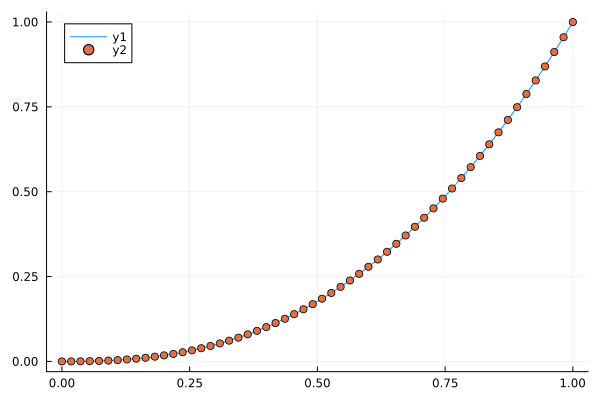

In [11]:
q₀ = 0.0 ;  p₀ = 0.0 ; N = 55 ; T = 1; 

ts = (0:N)*T/N;

exact(t)=t^2.5;

q = LobattoGalerkin(q₀ ,  p₀, α ,  N , T)[1:2:end]

plot(ts,ts .^2.5)
scatter!(ts,q)

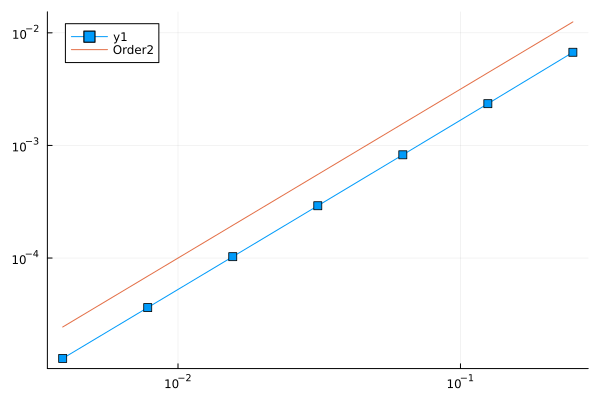

In [18]:
Ns=2 .^(2:8)

T = 1;

m = length(Ns);

err = zeros(m)

for i in 1:m

N = Ns[i]; ts = (0:N)*T/N;
    
q  = LobattoGalerkin(q₀ ,  p₀, α ,  N , T)[1:2:end]

err[i] = norm(q .- exact.(ts), Inf)
end    

h = T ./Ns;

f(x)=0.1*x^1.5;


plot(h , err , m =:sq)
plot!(h , f.(h) , label="Order2")
plot!(xscale=:log10, yscale=:log10, legend=:topleft)

#savefig("VI_midpointRKCQ")

In [ ]:
writedlm("/home/hariz/Desktop/RKCQ_1206/errors/3s_Lob_05.dat", [h err])